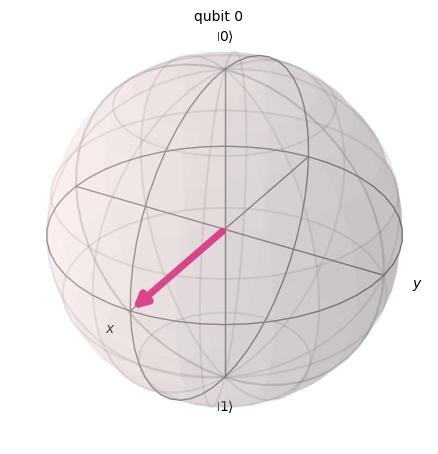

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import numpy as np
 

state = Statevector([1/np.sqrt(2), 1/np.sqrt(2)])
plot_bloch_multivector(state)



# Quantum states Bloch sphere

Examine how certain states appear on the sphere. To do this, pick at least 4 states, the first two of which should be |0> and |1>. (Additional states are recommended, where alpha and beta are equal, and at least one completely free choice.). How does it appear on the sphere if two states are orthogonal?

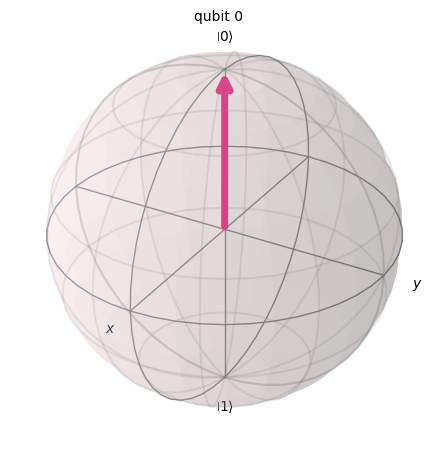

In [2]:
#quantum circuit
qc = QuantumCircuit(1,1) # 1 quantum and 1 classical bit (to store measurement results)
#quantum gates
qc.initialize([1/np.sqrt(2), 1/np.sqrt(2)], 0) #initialize the state of the quantum circuit
#different gates
qc.h(0)
qc.x(0)
qc.y(0)
qc.z(0)

#phase gate
theta = np.pi
qc.p(theta, 0)

#bloch visualization
state = Statevector(qc)
plot_bloch_multivector(state)

# Operations on the Bloch Sphere

Examination of X,Y,Z gates: What operation do these gates perform on the sphere, and why are they named as such? Examination of H gate: What does the H gate do? Prove that HXH=Z.

In [3]:


#measurement
qc.measure(range(1),range(1)) #what qubits to measure and where to write the results
qc.draw() #we can also draw the circuit

┌─────────────────────────────┐┌───┐┌───┐┌───┐┌───┐┌──────┐┌─┐
  q: ┤ Initialize(0.70711,0.70711) ├┤ H ├┤ X ├┤ Y ├┤ Z ├┤ P(π) ├┤M├
     └─────────────────────────────┘└───┘└───┘└───┘└───┘└──────┘└╥┘
c: 1/════════════════════════════════════════════════════════════╩═
                                                                 0

In [4]:
from qiskit_aer import Aer
from qiskit import transpile

#select simulator
backend = Aer.get_backend('qasm_simulator')
job_sim = backend.run(transpile(qc, backend), shots=1000,memory=True) #do 1000 measurements to collect statistics

result_sim = job_sim.result() 

counts = result_sim.get_counts()
print(counts) #print the measurement results

{'0': 1000}


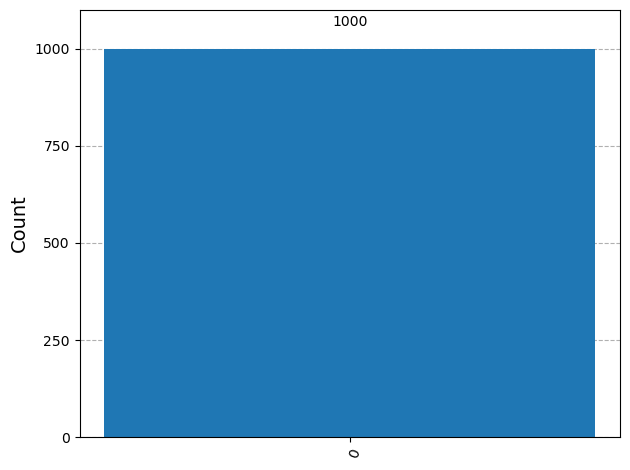

In [5]:
from qiskit.visualization import plot_histogram

#histogram of the results
plot_histogram(counts)

# Measuring a qubit
Which region on the sphere belongs to a certain measurement result (e.g.: 50-50\% that I measure 1 or 0)? What is the state after the measurement? What is the state after the measurement after multiple measurements?

# Measurement in different bases
Perform a measurement in the basis |+>, |->! What region on the sphere does a certain measurement result belong to? What is the state after the measurement?

# Preparing arbitrary qubit states
Examine the operation of the P phase-shift gate! Create a network capable of preparing any one-bit quantum state with its help!